# Vodafone Music Subscription Prediction

## Final Report

**Purpose of this notebook:**

Consolidate all results from Sprint 1–3 into a single readable report.
This notebook serves as the project summary for the GitHub repository.

**Outline:**
1. Business Problem
2. Data Overview
3. Key EDA Findings
4. Feature Engineering Summary
5. Modelling Results — All Sprints
6. Final Model Performance
7. Business Recommendations
8. Project Limitations & Next Steps

### 1. Business Problem

**Company:** Vodafone Ukraine

**Task:** Predict whether a subscriber will purchase the **Music** service (binary classification).

**Target variable:**
- `1` — subscribed to Music service (~7.6% of users)
- `0` — not subscribed (~92.4% of users)

**Business value:**

| Use case | Impact |
|---|---|
| Target only likely subscribers | Reduce marketing spend |
| Avoid false positives | No wasted outreach budget |
| Identify new subscribers early | Increase Music revenue |

**Primary metric:** ROC-AUC — standard for imbalanced binary classification.
Accuracy is misleading here (predicting all 0 gives 92.4% accuracy but zero business value).


### 2. Data Overview

                        Property                             Value
                          Source Kaggle — Vodafone Music Challenge
                            Rows                            70,000
               Original features                               461
         Features after cleaning                               430
      Features after engineering                               576
    Features used in final model                               514
    Positive class (subscribers)                    5,301  (7.57%)
Negative class (non-subscribers)                  64,699  (92.43%)
                 Imbalance ratio                          12.2 : 1


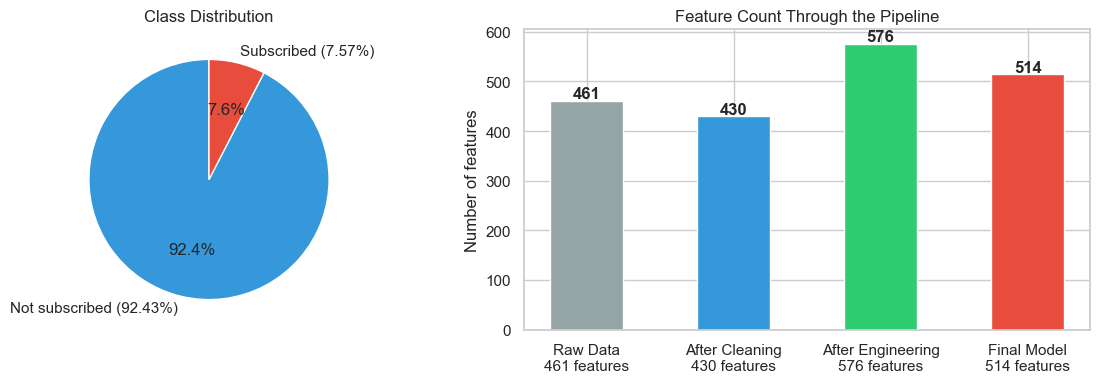

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Load final results
with open('../models/final_results.json') as f:
    final = json.load(f)

# Data overview table
overview = pd.DataFrame([
    ['Source', 'Kaggle — Vodafone Music Challenge'],
    ['Rows', '70,000'],
    ['Original features', '461'],
    ['Features after cleaning', '430'],
    ['Features after engineering', '576'],
    ['Features used in final model', str(final['n_features_used'])],
    ['Positive class (subscribers)', '5,301  (7.57%)'],
    ['Negative class (non-subscribers)', '64,699  (92.43%)'],
    ['Imbalance ratio', '12.2 : 1'],
], columns=['Property', 'Value'])

print(overview.to_string(index=False))

# Class distribution pie
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    [92.43, 7.57],
    labels=['Not subscribed (92.43%)', 'Subscribed (7.57%)'],
    colors=['#3498db', '#e74c3c'],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_title('Class Distribution')

# Sprint pipeline
stages = ['Raw Data\n461 features', 'After Cleaning\n430 features',
          'After Engineering\n576 features', 'Final Model\n' + str(final['n_features_used']) + ' features']
values = [461, 430, 576, final['n_features_used']]
colors_bar = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']
axes[1].bar(stages, values, color=colors_bar, width=0.5)
axes[1].set_title('Feature Count Through the Pipeline')
axes[1].set_ylabel('Number of features')
for i, v in enumerate(values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Key EDA Findings

| Finding | Detail |
|---|---|
| Strongest predictor | `lt` (tenure) — newer customers more likely to subscribe (r = -0.186) |
| Content engagement | `content_count_m*` consistently positive across all 3 months |
| Service signal | `service_9_flag_m*` — having this service = higher subscription probability |
| Negative signal | `service_P_flag_m*` — having service P = lower subscription probability |
| Non-linear features | `balance_sum`, `income_brnd_cont_m*` — weak Pearson but high Mutual Information |
| High cardinality | `manufacturer_category` (479 values) — required target encoding |
| Structural missingness | 449/461 columns had NaN — treated as absence of activity (filled 0) |
| Temporal patterns | Activity trends (m1−m3) add predictive signal beyond raw values |


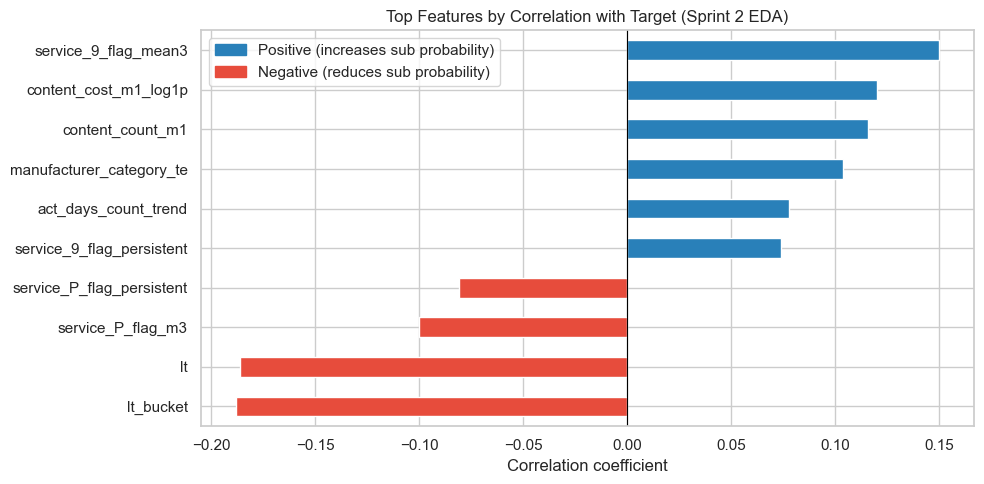

In [2]:
# Top features visualization
top_features = {
    'lt': -0.186,
    'service_9_flag_mean3': 0.150,
    'content_count_m1': 0.116,
    'manufacturer_category_te': 0.104,
    'service_P_flag_m3': -0.100,
    'lt_bucket': -0.188,
    'content_cost_m1_log1p': 0.120,
    'service_9_flag_persistent': 0.074,
    'service_P_flag_persistent': -0.081,
    'act_days_count_trend': 0.078,
}

feat_series = pd.Series(top_features).sort_values()
colors = ['#e74c3c' if v < 0 else '#2980b9' for v in feat_series]

plt.figure(figsize=(10, 5))
feat_series.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Features by Correlation with Target (Sprint 2 EDA)')
plt.xlabel('Correlation coefficient')
red_patch = mpatches.Patch(color='#e74c3c', label='Negative (reduces sub probability)')
blue_patch = mpatches.Patch(color='#2980b9', label='Positive (increases sub probability)')
plt.legend(handles=[blue_patch, red_patch])
plt.tight_layout()
plt.show()

### 4. Feature Engineering Summary

| Technique | Created | Kept | Best example |
|---|---|---|---|
| Temporal trends (m1 − m3) | 108 | 64 | `act_days_count_trend` (r=0.078) |
| Temporal aggregates (mean3) | 108 | 73 | `service_9_flag_mean3` (r=0.150) |
| Persistence flags | 3 | 3 | `service_P_flag_persistent` (r=-0.081) |
| Log1p transforms | 25 | 11 | `content_cost_m1_log1p` (r=0.120 vs 0.045 original) |
| Tenure binning | 1 | 1 | `lt_bucket` (r=-0.188) |
| Target encoding | 1 | 1 | `manufacturer_category_te` (r=0.104) |
| **Total engineered** | **246** | **153** | |

**Key insight:** Log transformation of `content_cost_m1` improved correlation by **2.7×** (0.045 → 0.120),
confirming heavy right-skew in content cost distribution.


### 5. Modelling Results — All Sprints

Sprint 3 results loaded from file
          Model  CV AUC  Val AUC
        XGBoost  0.8178   0.8352
       CatBoost  0.8226   0.8343
       LightGBM  0.8105   0.8248
XGBoost (tuned)  0.8269   0.8371

=== All Models Results ===
 Sprint                               Model  CV AUC  Val AUC  Avg Precision
      2                 Logistic Regression  0.7892   0.8013         0.2674
      2                       Random Forest  0.8023   0.8158         0.2831
      2                            LightGBM  0.8087   0.8261         0.3125
      3 XGBoost (tuned) (selected features)  0.8269   0.8371         0.3265


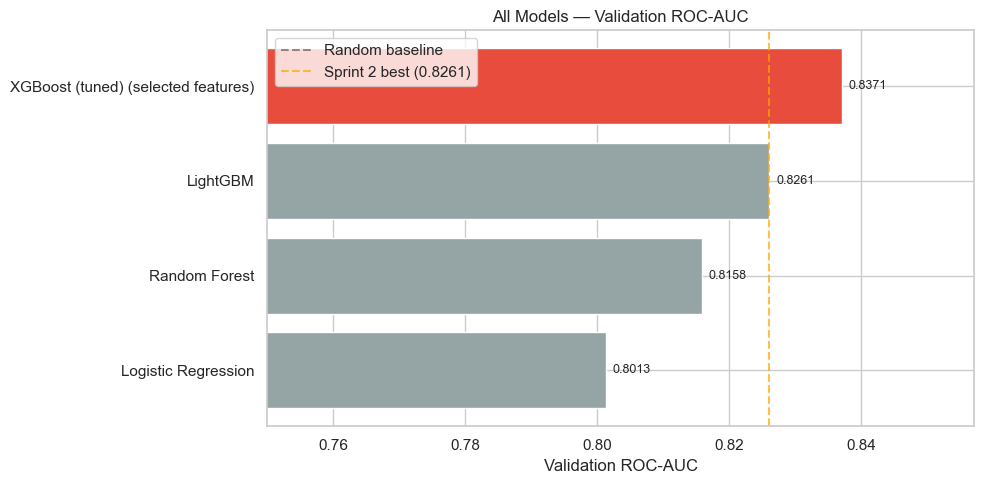

In [3]:
# Load Sprint 2 baseline
sprint2 = {
    'Logistic Regression': {'cv': 0.7892, 'val': 0.8013, 'ap': 0.2674, 'sprint': 2},
    'Random Forest':       {'cv': 0.8023, 'val': 0.8158, 'ap': 0.2831, 'sprint': 2},
    'LightGBM (baseline)': {'cv': 0.8087, 'val': 0.8261, 'ap': 0.3125, 'sprint': 2},
}

# Load Sprint 3 results from file
try:
    sprint3_results = pd.read_csv('../models/sprint3_results.csv')
    print('Sprint 3 results loaded from file')
    print(sprint3_results.to_string(index=False))
except FileNotFoundError:
    print('Sprint 3 results file not found — run notebook 06 first')

# Full results table
results_df = pd.DataFrame([
    {'Sprint': 2, 'Model': 'Logistic Regression', 'CV AUC': 0.7892, 'Val AUC': 0.8013, 'Avg Precision': 0.2674},
    {'Sprint': 2, 'Model': 'Random Forest',       'CV AUC': 0.8023, 'Val AUC': 0.8158, 'Avg Precision': 0.2831},
    {'Sprint': 2, 'Model': 'LightGBM',            'CV AUC': 0.8087, 'Val AUC': 0.8261, 'Avg Precision': 0.3125},
    {'Sprint': 3, 'Model': f"{final['best_model']} (selected features)",
     'CV AUC': final['cv_auc'], 'Val AUC': final['val_auc'], 'Avg Precision': final['val_ap']},
])

print('\n=== All Models Results ===')
print(results_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors_sprint = ['#95a5a6'] * 3 + ['#e74c3c']
bars = ax.barh(results_df['Model'], results_df['Val AUC'], color=colors_sprint)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.4, label='Random baseline')
ax.axvline(0.8261, color='orange', linestyle='--', alpha=0.7, label='Sprint 2 best (0.8261)')
ax.set_xlabel('Validation ROC-AUC')
ax.set_title('All Models — Validation ROC-AUC')
ax.set_xlim(0.75, max(results_df['Val AUC']) + 0.02)
for bar, val in zip(bars, results_df['Val AUC']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

### 6. Final Model Performance

In [4]:
print('=== FINAL MODEL SUMMARY ===')
print(f'Model:              {final["best_model"]}')
print(f'Validation ROC-AUC: {final["val_auc"]}')
print(f'Avg Precision:      {final["val_ap"]}')
print(f'CV ROC-AUC:         {final["cv_auc"]} ± {final["cv_std"]}')
print(f'Optimal threshold:  {final["optimal_threshold"]}')
print(f'Features used:      {final["n_features_used"]}')
print(f'Improvement vs S2:  +{final["val_auc"] - final["baseline_auc_sprint2"]:.4f} AUC')

=== FINAL MODEL SUMMARY ===
Model:              XGBoost (tuned)
Validation ROC-AUC: 0.8371
Avg Precision:      0.3265
CV ROC-AUC:         0.8269 ± 0
Optimal threshold:  0.69
Features used:      514
Improvement vs S2:  +0.0110 AUC


### 7. Business Recommendations

Based on the model findings, here are actionable recommendations for Vodafone:

**Who to target:**
- **New subscribers** (`lt` < 0.4) — strongest signal, highest subscription rate
- Users with active **content consumption** (`content_count_m1` high)
- Users who already have **service_9** active — high cross-sell potential

**Who to deprioritise:**
- Long-tenure customers (`lt` > 0.85) — already settled into usage patterns
- Users with **service_P** active across all 3 months — consistently negative signal

**Deployment recommendation:**
- Use **classification threshold = optimal** (not default 0.5)
  to balance Precision vs Recall based on campaign budget
- Higher threshold → fewer contacts, higher conversion rate (Precision focus)
- Lower threshold → more contacts, catch more subscribers (Recall focus)

**Model refresh:** Retrain monthly — `_m1/_m2/_m3` features are time-sensitive


### 8. Project Limitations & Next Steps

#### Limitations
- No hyperparameter tuning (Optuna) — default parameters used throughout
- Target encoding applied globally (potential leakage in strict CV setting)
- No ensemble/stacking of multiple models
- Feature interactions not explicitly modelled
- No access to test set labels — public leaderboard score unknown

#### Next Steps
| Step | Expected impact |
|---|---|
| Optuna hyperparameter tuning | +0.005–0.015 AUC |
| Proper CV-based target encoding | Reduced leakage risk |
| Model stacking (LGB + XGB + CB) | +0.003–0.008 AUC |
| Interaction features (e.g. lt × content_count) | Unknown |
| SHAP values for interpretability | Better business explainability |
